# SPCImage Data Analysis

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import itertools


# from pyfli import GlobalFLIFitter, FittingComparator
# from pyfli import Fli_CPUProcessor, Fli_GPUProcessor
# from pyfli import Msg_display



from pyfli import DataOperations, Normalization
from pyfli.data_cc import IRFAligner, DataPreprocessing
from pyfli.analytical_methods import PhasorAnalyzer, AnalyticalHelpers
from pyfli.data_vnp import DataViewer, ColorProcessor
from pyfli.io import DataIOUtils, DataSaver
from pyfli.solver import MLEFLIFitter, BaseFLIFitter, BinnedFLIFitter, FLIBinner, FLICPUProcessor, FLIGPUProcessor
from pyfli.roi_maker import ROIMaker
from pyfli.analysis.utils import random_true_pixel

In [ ]:
# making the zero values to black
jet_m = ColorProcessor().lowest_zero('jet')
plasma_m = ColorProcessor().lowest_zero('plasma')
magma_m = ColorProcessor().lowest_zero('magma   ')

###### Load SPCImage data through single .sdt files and irf either .txt or .asc file and mask if already designed

In [4]:
# Align folder/file paths for analysis
data_path = "../data/spheroids/Exp 18_AU565_DL2-1.sdt"
irf_path = "../data/irfs/SPCimage_IRF.txt"
bg_path = None
mask_path = None
roiN_mask_path = None
loader = DataOperations(    
    data_path= data_path,
    irf_path= irf_path, 
    bg_path = None,   
    mask_path= None
    )
decay_raw = loader.load_data()
irf_raw = loader.load_irf()
print(decay_raw.shape)
print(irf_raw.shape)

INFO:pyfli:Initiating DATA load from: ../data/spheroids/Exp 18_AU565_DL2-1.sdt
INFO:pyfli:Initiating IRF load from: ../data/irfs/SPCimage_IRF.txt


(512, 512, 256)
(512, 512, 256)


In [5]:
MODEL_TYPE = ['mono-exponential', 'bi-exponential'][1]
import os

# Saving/loading the data
saver_active = True
free_memory  = True

data_load    = False
if data_load:
    saved_data_path = 'RPI_sim_test'
    auto_save    = False
else:
    saved_data_path   = None             # manual load path (used only if auto_save=False);
                                      # leave None to auto-derive from manual_save_root + save_suffix
    auto_save    = True                 # False if data_load is true

new_session  = False

# data_path    = None             # source data (used only if auto_save=True)

manual_save_root  = f"simRPI_{MODEL_TYPE}_v1"    # manual save root (used only if auto_save=False)
bin_r = 0
save_suffix = f"bin{bin_r}_pf_Analysis"


saver = None
if saver_active:
    if auto_save:
        if not data_path:
            raise ValueError("auto_save=True requires data_path to be set.")
        data_saving_folder = (
            data_path if os.path.isfile(data_path)
            else os.path.join(os.path.dirname(data_path), f"{os.path.basename(data_path)}_")
        )
        target_dir = DataSaver.resolve_path(data_saving_folder, save_suffix)

        if data_load:
            saver = DataSaver.load(target_dir)
            print(f'Data loaded (auto-derived path) - Session: "{saver.save_dir}"')
        else:
            saver = DataSaver(path=data_saving_folder, folder_name=save_suffix,
                               new_session=new_session)
            print(f'Data Saving (auto-derived path) - Session: "{saver.save_dir}"')
    else:
        if data_load:
            load_target = (
                saved_data_path if saved_data_path
                else DataSaver.resolve_path(manual_save_root, save_suffix)
            )
            saver = DataSaver.load(load_target)
            print(f'Data loaded - Session: "{saver.save_dir}"')
        else:
            saver = DataSaver(path=manual_save_root, folder_name=save_suffix,
                               new_session=new_session)
            print(f'Data Saving - Session: "{saver.save_dir}"')
else:
    print("This session decides not to save any data")

Data Saving (auto-derived path) - Session: "../data/spheroids/Exp 18_AU565_DL2-1bin0_pf_Analysis"


In [6]:
load_this = False
if load_this:
    binned_decay = saver.load_npy('clean_decay')
    print(f'The shape of Decay data is: {binned_decay.shape}')

    binned_irf = saver.load_npy('clean_irf')
    print(f'The shape of IRF data is: {binned_irf.shape}')

    b_bool_mask = saver.load_npy('final_mask')
    print(f'The shape of Bool_mask is: {b_bool_mask.shape}')


    gate_delay = 12.5/binned_irf.shape[2]
    # gate_delay = 0.04
    num_gates = binned_irf.shape[2]
    freq = AnalyticalHelpers(laser_period = 12.5, gate_delay=gate_delay, num_gate = num_gates).freq_computation() 
    print(f'the effective frequency is {freq[1]} MHz')
    freq_hz = freq[1] * 1e6
    time_axis_ns = np.linspace(0, gate_delay*num_gates, binned_irf.shape[2])

In [7]:
draw_pf_roi   = [False, True][0]
if saver_active:
    _base_path    = os.path.join(saver.save_dir, "pf_mask.npy")
    _stem         = os.path.splitext(_base_path)[0]
    

    _path_binary    = f"{_stem}_binary.npy"
    _path_multi     = f"{_stem}_multi.npy"
    _path_threshold = f"{_stem}_threshold_binary.npy"
else:
    _base_path    = None
    _stem         = None

map_array     = np.ones(decay_raw.shape[:2], dtype=bool)


binary_mask    = None   # polygon-filled ROI binary (bool)
multi_mask     = None   # integer-labeled cluster mask
threshold_mask = None   # intensity-threshold binary (no polygon fill)

In [8]:
print(_path_threshold)

../data/spheroids/Exp 18_AU565_DL2-1bin0_pf_Analysis/pf_mask_threshold_binary.npy


Threshold mask loaded ← ../data/spheroids/Exp 18_AU565_DL2-1bin0_pf_Analysis/pf_mask_threshold_binary.npy
No ROI found — using full image.


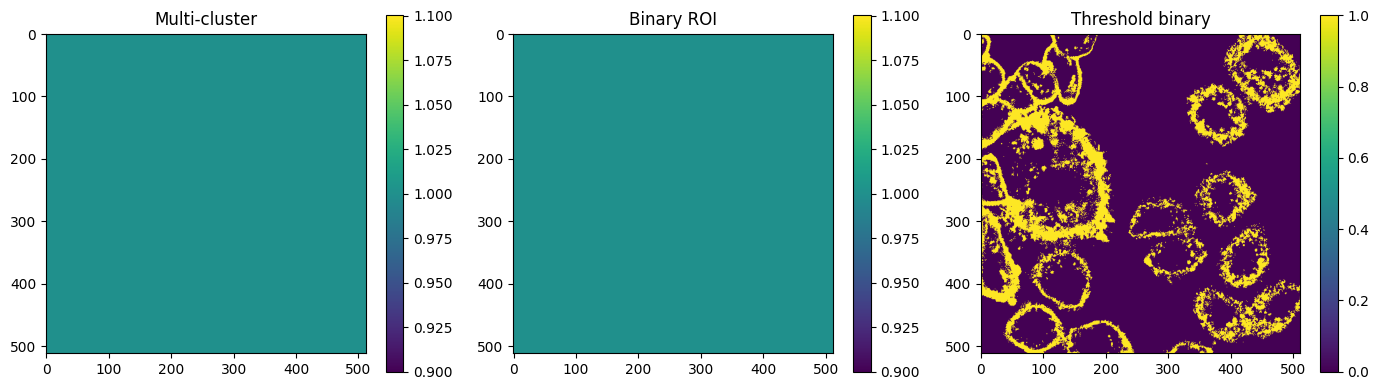

In [9]:
if roiN_mask_path:
    binary_mask = DataIOUtils().roiNloader(map_array=map_array, file_path=roiN_mask_path).astype(bool)
    print(f'roiN mask loaded: {binary_mask.shape}')

elif mask_path:
    binary_mask = DataIOUtils().roiNloader(map_array=map_array, file_path=mask_path).astype(bool)
    print(f'Standard mask loaded: {binary_mask.shape}')

elif draw_pf_roi:
    roi_maker = ROIMaker(np.sum(decay_raw, axis=-1), save_path=_base_path)
    roi_maker.draw()

    binary_mask    = roi_maker.get_binary_mask()
    multi_mask     = roi_maker.get_multi_cluster_mask()
    threshold_mask = roi_maker.get_threshold_binary_mask()

    if binary_mask.any():    np.save(_path_binary,    binary_mask);    print(f"Saved → {_path_binary}")
    if multi_mask.max() > 0: np.save(_path_multi,     multi_mask);     print(f"Saved → {_path_multi}")
    if threshold_mask.any(): np.save(_path_threshold, threshold_mask); print(f"Saved → {_path_threshold}")

else:  # load previously saved masks
    if os.path.exists(_path_multi):
        multi_mask  = np.load(_path_multi)
        binary_mask = (multi_mask > 0).astype(bool)   # fallback binary from multi
        print(f'Multi mask loaded: {np.unique(multi_mask[multi_mask > 0]).size} clusters ← {_path_multi}')
    if os.path.exists(_path_binary):
        binary_mask = np.load(_path_binary).astype(bool)   # overrides multi fallback
        print(f'Binary mask loaded ← {_path_binary}')
    if os.path.exists(_path_threshold):
        threshold_mask = np.load(_path_threshold)
        print(f'Threshold mask loaded ← {_path_threshold}')
    if binary_mask is None:
        binary_mask = map_array
        print('No ROI found — using full image.')

# Downstream references
_mask         = binary_mask
_cluster_mask = multi_mask   # None when only binary/threshold was drawn

# ── Display ───────────────────────────────────────────────────────────────────
_display = _cluster_mask if _cluster_mask is not None else _mask
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, title in zip(axes,
    [_display,          _mask,            threshold_mask],
    ['Multi-cluster',   'Binary ROI',     'Threshold binary']):
    if data is not None:
        im = ax.imshow(data); plt.colorbar(im, ax=ax)
    else:
        ax.axis('off')
    ax.set_title(title)
plt.tight_layout(); plt.show()

In [10]:
b_bool_mask = [_cluster_mask, _mask, threshold_mask][-1]

In [11]:

times = (2*bin_r+1)*(2*bin_r+1)
print(f'the multiplication factor in comparison to unbinned is: {times}')
binner = FLIBinner(bin_radius=bin_r)
b_decay, b_irf = binner.apply_binning(decay_raw, irf_raw)

the multiplication factor in comparison to unbinned is: 1


INFO:pyfli:Applying spatial binning: Radius=0 (1x1 window)


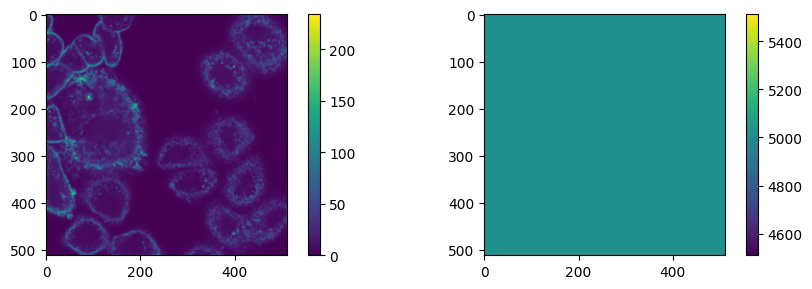

In [12]:
# bin has been applied
fig, axes = plt.subplots(1,2, figsize=(9,3))
im0 = axes[0].imshow(np.sum(b_decay, axis=2))
fig.colorbar(im0, ax =axes[0])
im1 = axes[1].imshow(np.sum(b_irf, axis=2))
fig.colorbar(im1, ax =axes[1])
plt.tight_layout()
plt.show()

In [13]:
b_irf_corr = IRFAligner(b_decay, b_irf)

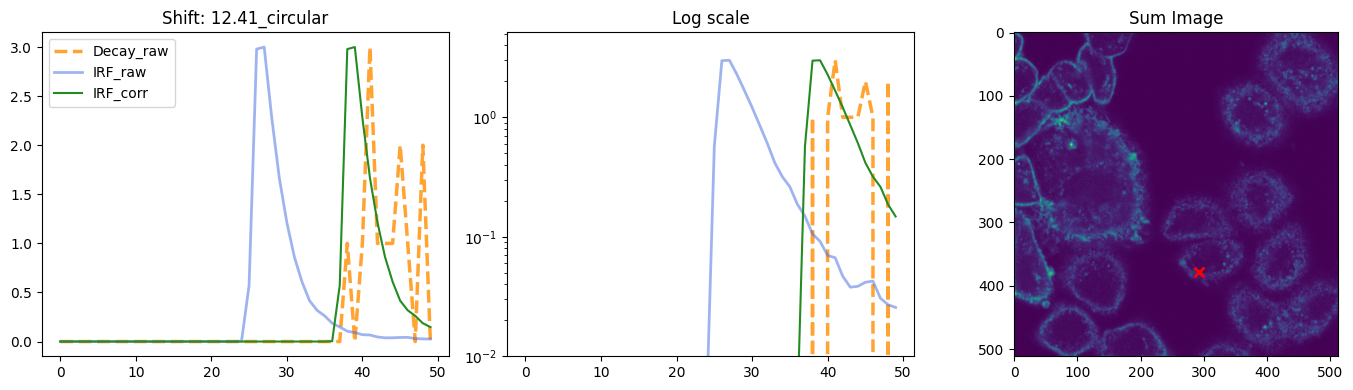

In [14]:
x,y = random_true_pixel(b_bool_mask)
fraction = 0.15
method_ = ['fourier', 'circular'][1]
manual_correction = 0.4


shift_, shift_num = b_irf_corr.align_pixel(x,y,fraction=fraction, method= method_, manual_correction=manual_correction)

st_, till_ = 0, 50
dec_p = b_decay[x,y,st_:till_]
irf_p = Normalization(b_irf[x,y,st_:till_]).norm_scale(dec_p)
irf_shift_p = Normalization(shift_[st_:till_]).norm_scale(dec_p)


# Adjust these values 
decay_alpha = 0.8
irf_alpha = 0.5
shift_alpha = 1.0
# ------------------------------

fig, axes = plt.subplots(1, 3, figsize=(14, 4)) 

# Subplot 0 - Linear Scale
axes[0].plot(dec_p, color='darkorange', linewidth=2.5, linestyle='--', alpha=decay_alpha, label='Decay_raw')
axes[0].plot(irf_p, color='royalblue', linewidth=2.0, linestyle='-', alpha=irf_alpha, label='IRF_raw')
axes[0].plot(irf_shift_p, color='forestgreen', linewidth=1.5, linestyle='-', alpha=shift_alpha, label='IRF_corr')
axes[0].set_title(f'Shift: {shift_num:.2f}_{method_}')


axes[0].legend()

# Subplot 1 - Log Y Scale (Same data as Subplot 0)
axes[1].plot(dec_p, color='darkorange', linewidth=2.5, linestyle='--', alpha=decay_alpha)
axes[1].plot(irf_p, color='royalblue', linewidth=2.0, linestyle='-', alpha=irf_alpha)
axes[1].plot(irf_shift_p, color='forestgreen', linewidth=1.5, linestyle='-', alpha=shift_alpha)
axes[1].set_yscale('log') 
axes[1].set_ylim(bottom=0.01)
axes[1].set_title('Log scale')

# Subplot 2 - Image and Scatter
axes[2].imshow(np.sum(b_decay, axis=-1), cmap='viridis')
axes[2].scatter(y, x, marker='x', color='red', s=50, linewidths=2) 
axes[2].set_title('Sum Image')
axes[2].set_box_aspect(1)

# bbox_inches='tight' ensures the outside legend does not get cut off when saving or rendering
plt.tight_layout()
plt.show()


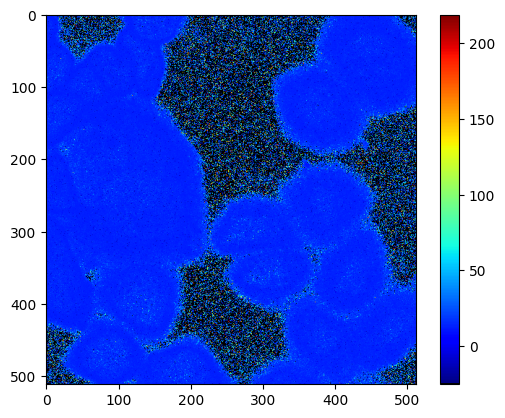

In [15]:
b_irf_shifted, b_shifts = b_irf_corr.align(fraction=fraction, method= method_, manual_correction=manual_correction)
plt.imshow(b_shifts, cmap=jet_m)
plt.colorbar()
plt.show()

In [16]:
###### pixel invariant IRF creation
pixel_invariant = True # False is default for ICCD
if pixel_invariant:
    decay_intensity = np.sum(b_decay, axis=2)
    x_px, y_px = np.unravel_index(np.argmax(decay_intensity), decay_intensity.shape)
    b_m_irf = np.tile(b_irf_shifted[x_px, y_px,:],(512,512,1))
    print(b_m_irf.shape)
else:
    b_m_irf = b_irf_shifted

(512, 512, 256)


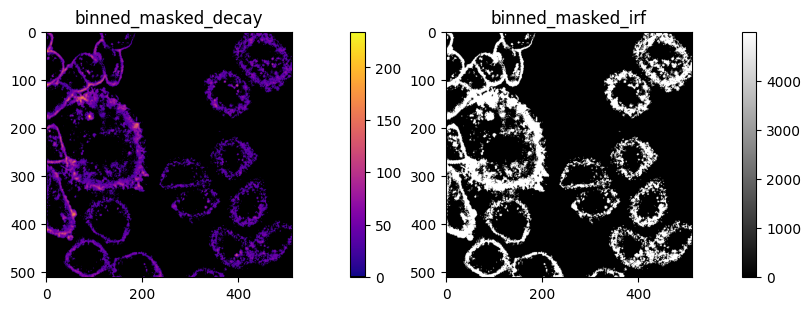

(<Figure size 1200x300 with 4 Axes>,
 [<Axes: title={'center': 'binned_masked_decay'}>,
  <Axes: title={'center': 'binned_masked_irf'}>],
 None)

In [17]:
binned_datac = DataPreprocessing(b_decay, b_m_irf)
# b_bool_mask = binned_datac.threshold_masking(lower=threshold_min*times, upper=threshold_max*times)
b_fli_masked, b_irf_masked = binned_datac.apply_mask(mask = b_bool_mask)

data_list2 = [b_fli_masked, b_irf_masked ]
data_names2 = ['binned_masked_decay', 'binned_masked_irf']
cmaps = [plasma_m, "grey"]
px = None
DataViewer(save_path=saver.save_dir, fig_name='masked').display_data(data_list2, structure=(1, 3), coord=px, data_names=data_names2, 
                     cmaps=cmaps, v_ranges=None, figsize=(12,3), normalize=False, yscale = 'linear')

In [18]:
binned_decay, binned_irf = b_fli_masked, b_irf_masked
if free_memory:
    del b_decay, b_m_irf, b_fli_masked, b_irf_masked
save_this = False
if save_this:
    saver.save_npy('clean_decay', binned_decay)
    saver.log('The clean decay saved')
    saver.save_npy('clean_irf', binned_irf)
    saver.log('The clean irf saved')
    saver.save_npy('final_mask', b_bool_mask)
    saver.log('final bool mask saved')

In [19]:
# Set-up (Camera Acquisition) parameters
gate_delay = 12.5/binned_irf.shape[2]
# gate_delay = 0.04
num_gates = binned_irf.shape[2]
freq = AnalyticalHelpers(laser_period = 12.5, gate_delay=gate_delay, num_gate = num_gates).freq_computation() 
print(f'the effective frequency is {freq[1]} MHz')
freq_hz = freq[1] * 1e6
time_axis_ns = np.linspace(0, gate_delay*num_gates, binned_irf.shape[2])
h_p_offset = b_shifts*gate_delay
saver.save_npy("H_P_offset", h_p_offset)

INFO:pyfli:Array saved: >> H_P_offset.npy | Shape: (512, 512)


the effective frequency is 80.0 MHz


In [22]:
# colorset = ['winter', 'managua', 'grey', 'magma', 'summer', 'pink' ][-1]  # default is autumn
# colorset = ['viridis', 'plasma', 'inferno', 'magma', 'cividis'][1]
colorset = [ 'ocean', 'gist_earth', 'terrain',
                      'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap',
                      'cubehelix', 'brg', 'gist_rainbow', 'rainbow', 'jet', 'jet_r',
                      'turbo', 'nipy_spectral', 'gist_ncar'][-6]

# colorset = ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu',
#                       'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic',
#                       'berlin', 'managua', 'vanimo'][-1]


In [23]:
Phasor_binned = PhasorAnalyzer(frequency_hz=freq_hz, time_axis_ns=time_axis_ns, n_harmonics=3)
# Phasor computation (3-HARMONICS computed here)
binned_G, binned_S = Phasor_binned.create_phasor_gpu(binned_decay)
binned_Gc, binned_Sc = Phasor_binned.calibrate_pixelwise(binned_G, binned_S, binned_irf) # pixelwise-IRF calibration
binned_tau_map_ns = Phasor_binned.compute_lifetime(binned_Gc[0], binned_Sc[0])

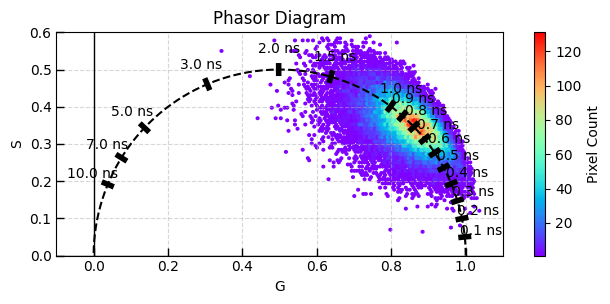

In [24]:
im1 = Phasor_binned.plot_phasor_diagram(binned_Gc[0], binned_Sc[0], 
                                        mask = b_bool_mask, 
                                        # colors = 'jet', 
                                        hexbin_color = colorset, 
                                        figsize = (7, 3),
                                        half_circle= True)


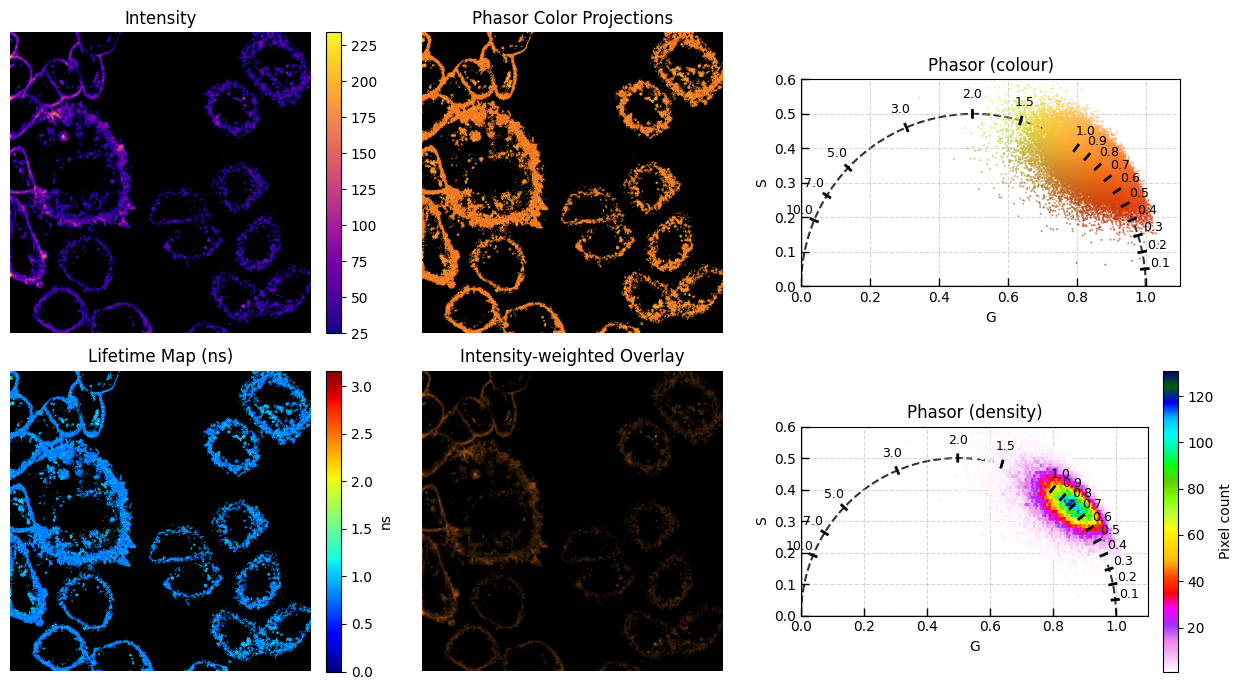

In [26]:
bg_color = ["black", "white"][0]
ph_cols_ = ["gist_ncar_r","PuBuGn", "YlGnBu", "BuPu", "viridis_r", "jet_r"][0]
im2 = Phasor_binned.plot_overlay_subplots(binned_decay,
                                    binned_Gc[0], binned_Sc[0],
                                    mask=b_bool_mask,
                                    colormaps =['plasma','jet', 'turbo_r', ph_cols_],
                                    figsize=(13, 7),
                                    xlim = (0, 1.1), 
                                    bg_color = bg_color, 
                                    transpose = False)

In [27]:
save_this = False
if save_this:
    saver.save_plot(name='Phasor_Plot', fig=im1, close=False)
    saver.save_plot(name='Phasor_subplots_'+bg_color, fig=im2, close=False)

#### Phasor Guess lifetime Fitting

Reconstructed decay shape: (512, 512, 256)


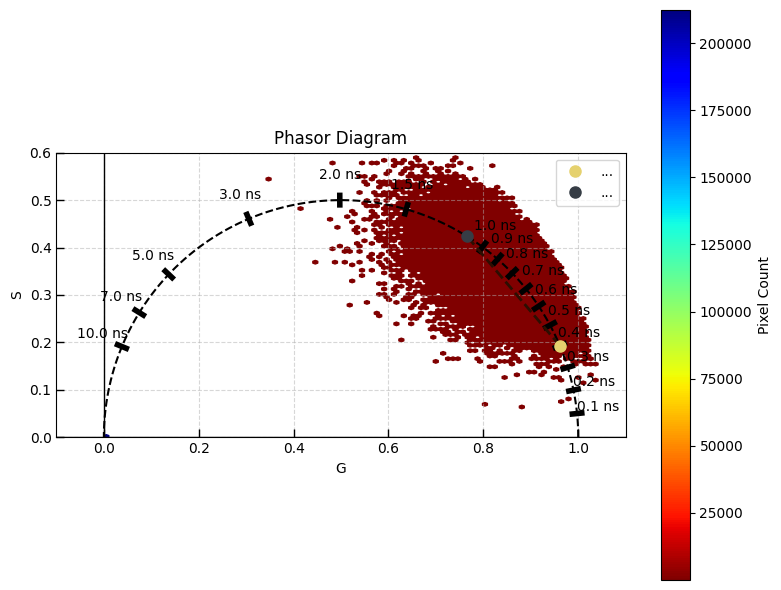

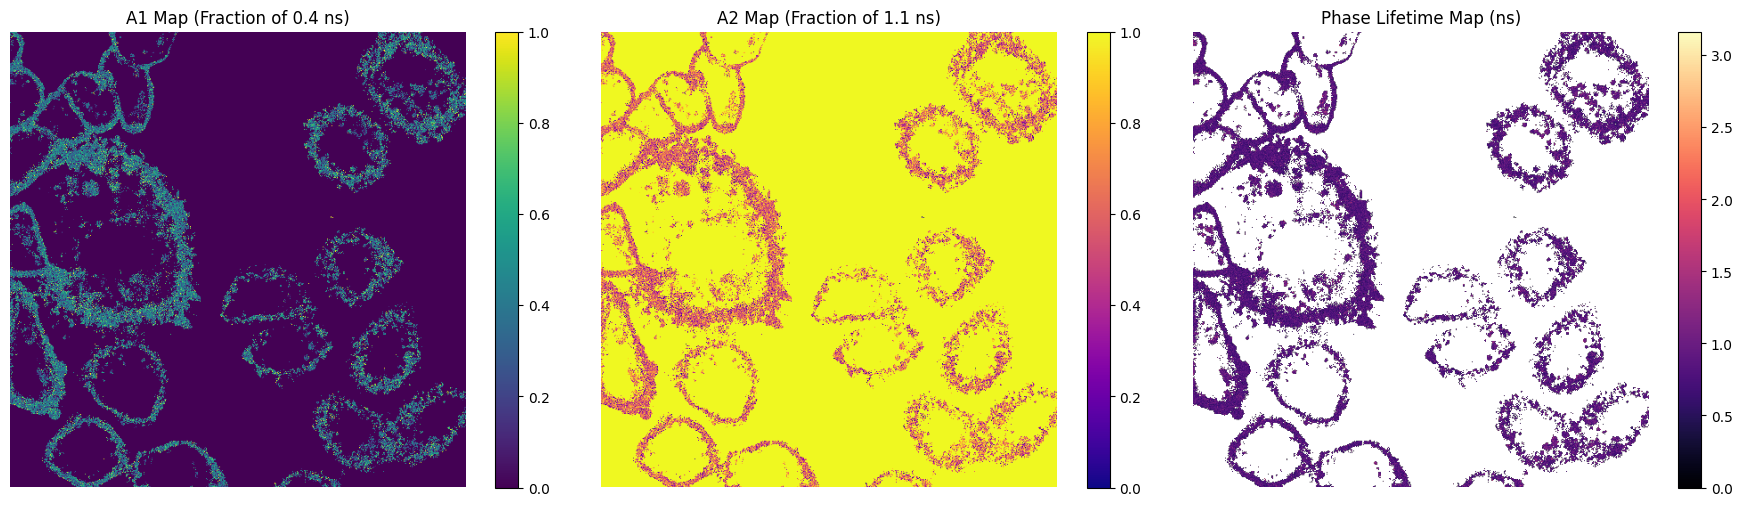

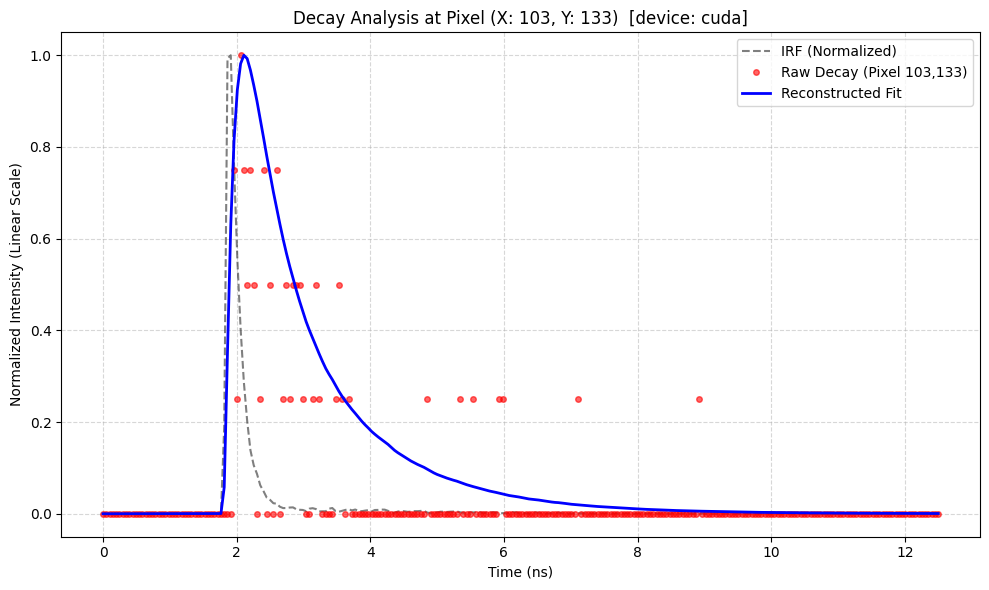

In [28]:
# user provided input 'tau1_ns', 'tau2_ns' and pixel (x,y)
x,y = random_true_pixel(b_bool_mask)
fitting_type = ['mono-exponential', 'bi-exponential'][1]

if fitting_type == 'mono-exponential':
    # user provided input 'tau_ns' and pixel (x,y)
    tau_ns = 0.9
    Phasor_binned.plot_pixel_fit_single_exp(binned_irf, binned_decay, binned_tau_map_ns, y, x, log_scale=False)
else:
    tau1_ns, tau2_ns = 0.4, 1.1
    A1, A2 = Phasor_binned.compute_fractions(binned_Gc[0], binned_Sc[0], tau1_ns, tau2_ns)
    reconstructed_decay = Phasor_binned.analyze_biexponential_and_reconstruct(
        binned_Gc[0], binned_Sc[0], binned_irf, tau1_ns=tau1_ns, tau2_ns=tau2_ns, plot=True
    )
    print(f"Reconstructed decay shape: {reconstructed_decay.shape}")
    # Checking if lifetime values selected makes sense
    Phasor_binned.plot_pixel_fit(binned_irf, binned_decay, reconstructed_decay, y, x, log_scale=False)



#### Analytical Fitting methods (NLSF/ MLE)


┌──────────────────────────────────────────────────────────────┐
│  FLI Fitting Results  |  BI-EXPONENTIAL                      │
│  6 methods queued                                            │
└──────────────────────────────────────────────────────────────┘


┌────────────────┬──────┬─────────┬─────────┬──────────┬──────────┬─────────┬──────────┬──────────┬─────────┬──────────┐
│ Method         │ Type │       A │       α │       τ₁ │       τ₂ │      R² │   Red.χ² │   Raw.χ² │ v-shift │  h-shift │
├────────────────┼──────┼─────────┼─────────┼──────────┼──────────┼─────────┼──────────┼──────────┼─────────┼──────────┤
│ LEAST_SQUARES  │ NLSF │    0.91 │  0.1407 │    0.130 │    1.686 │  0.3969 │   0.1242 │    31.05 │    0.00 │    0.293 │
│ TRUST_REGION   │ NLSF │    0.81 │  0.0958 │    0.045 │    1.569 │  0.4458 │   0.1037 │    25.92 │    0.00 │    0.342 │
│ UNCONSTRAINED  │ NLSF │    0.98 │  0.1225 │    0.073 │    1.733 │  0.4437 │   0.1036 │    25.91 │   -0.01 │    0.342 │
│ POISSON  

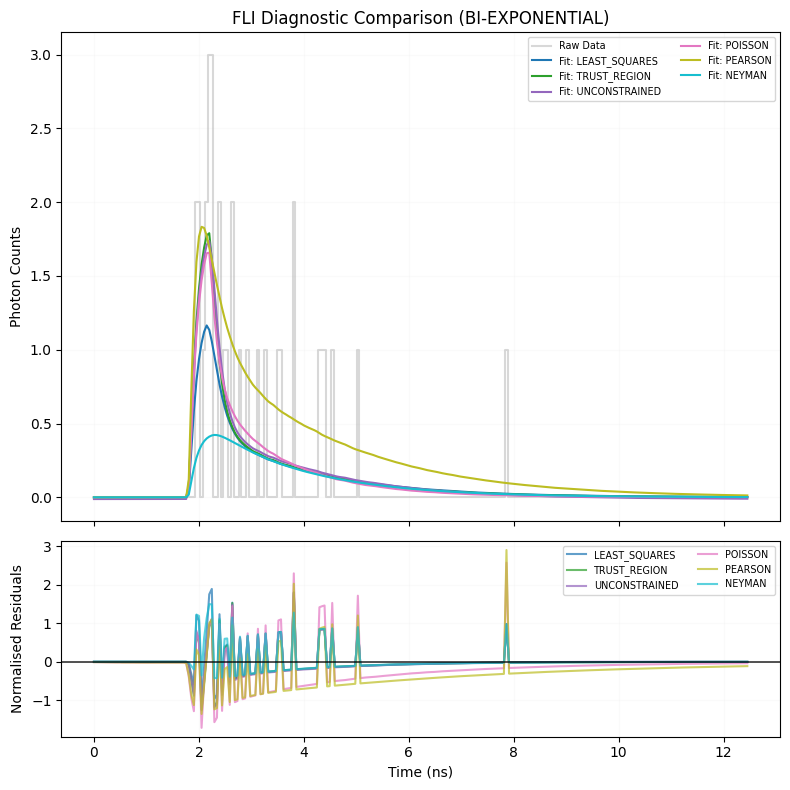

INFO:pyfli:IMAGE SAVED >> fitting_comparison_bi-exponential.png


In [29]:
from pyfli.solver import FittingComparator

# _MODEL_TYPE = ['mono-exponential', 'bi-exponential'][1]   # keep in sync with fitting loop below
_MODEL_TYPE = MODEL_TYPE
# _p0     = [1.0, 0.2, 1.1, 3.0, 0, 0]
# _bounds = [(0, np.inf), (0, 1), (0, 2), (0, 4), (0, np.inf),(0, np.inf)]

_p0     = None
_bounds = None

xd, yd = random_true_pixel(b_bool_mask)
pixel_decay = binned_decay[xd, yd, :]
pixel_irf   = binned_irf[xd, yd, :]

comparator = FittingComparator(freq, BaseFLIFitter, MLEFLIFitter)
comp_results_table, comp_fig = comparator.run_all(
    y_data     = pixel_decay,
    irf_data   = pixel_irf,
    model_type = _MODEL_TYPE,
    p0         = _p0,
    bounds     = _bounds,
    yscale     = 'linear',
    plot       = True
)

_ = comparator.save_results(saver, comp_results_table, fig=comp_fig,
                     model_type= MODEL_TYPE, name=f"fitting_comparison_{MODEL_TYPE}")

In [32]:
from pyfli.solver import GlobalFLIFitter, FittingComparator
from pyfli.solver import FLICPUProcessor, FLIGPUProcessor
from pyfli.data_text import MessageDisplay

save_this = True
run_mode = ['single', 'both', 'all'][1]  # 0 = one config, 1 = all combinations


DATA_MODE = ['macroscopy_', 'mesoscopy_', 'microscopy_', 'simulated_'][0]
EXP_NAME  = 'OMI periphery'

# --- Manual selection (only used when run_mode == 'single') ---
USE_GPU    = False   # True = GPU  |  False = CPU
USE_MLE    = False  # True = MLE  |  False = NLSF
MODEL_TYPE = ['mono-exponential', 'bi-exponential'][1]

# --- Iteration budget per (GPU, MLE) combination ---
# GPU  : LBFGS steps  — batch over all pixels simultaneously
# CPU  : scipy max function evaluations per pixel
MAX_ITER = {
    (True,  False): 1000,   # GPU  NLSF
    (True,  True):  1000,    # GPU  MLE  
    (False, False): 2000,   # CPU  NLSF
    (False, True):  1500,   # CPU  MLE
}

# Build run list
if run_mode == 'single':
    run_combinations = [(USE_GPU, USE_MLE)]
elif run_mode == 'both':
    run_combinations = [(USE_GPU, False), (USE_GPU, True)]
elif run_mode == 'all':
    run_combinations = list(itertools.product([False, True], [False, True]))
else:
    raise ValueError(f"Unknown run_mode: {run_mode}")


use_initial_guess = False
use_bounds        = False
full_data_name    = f"{DATA_MODE}{EXP_NAME}" if EXP_NAME else DATA_MODE


for USE_GPU, USE_MLE in run_combinations:
    processing_device = FLIGPUProcessor if USE_GPU else FLICPUProcessor
    fitter_class  = MLEFLIFitter if USE_MLE else BaseFLIFitter
    processor_name = 'GPU' if USE_GPU else 'CPU'
    fitter_name    = 'MLE' if USE_MLE else 'NLSF'
    estimator      = 'poisson' if USE_MLE else 'least_squares'
    max_iter       = MAX_ITER[(USE_GPU, USE_MLE)]

    # Initial guess & parameter bounds
    if use_initial_guess:
        p0 = ([1.0, 1.0, 0] if MODEL_TYPE == 'mono-exponential'
              else [1.0, 0.5, 0.5, 1.1, 0])
    else:
        p0 = None

    if use_bounds:
        bounds = ([(0, np.inf), (0, 2), (0, np.inf)]
                  if MODEL_TYPE == 'mono-exponential'
                  else [(0, np.inf), (0, 1), (0, 2), (0, 2), (0, np.inf)])
    else:
        bounds = None

    msg = MessageDisplay(saver=saver) if save_this else MessageDisplay()
    msg.fit_session(
        model_type        = MODEL_TYPE,
        processor_name    = processor_name,
        fitter_name       = fitter_name,
        estimator         = estimator,
        data_name         = full_data_name,
        use_initial_guess = use_initial_guess,
        p0                = p0,
        use_bounds        = use_bounds,
        bounds            = bounds,
        max_iter          = max_iter,
    )

    print(f"\n>>> Running Session: {processor_name} | {fitter_name} | {estimator} | max_iter={max_iter}")

    process_loader = processing_device(freq, fitter_class)
    fitter = BinnedFLIFitter(process_loader, bin_radius=bin_r)

    results = fitter.fit(
        b_img      = binned_decay,
        b_irf      = binned_irf,
        estimator  = estimator,
        model_type = MODEL_TYPE,
        n_jobs     = 7,
        data_name  = full_data_name,
        max_iter   = max_iter,
    )

    res_save_name = f'{processor_name}_{fitter_name}_{estimator}_{MODEL_TYPE}'
    saver.save_npy(res_save_name, results)
    saver.log(f'The computational result {res_save_name} saved')
    saver.log('-' * 40)

    if free_memory:
        del results

    print(f"Finished combination: GPU={USE_GPU}, MLE={USE_MLE}, max_iter={max_iter}")
    print("-" * 30)

INFO:pyfli:
------------------------------------------------------------
                   SESSION CONFIGURATION                    
------------------------------------------------------------
INFO:pyfli:Parameter: >> model_type: bi-exponential
INFO:pyfli:Parameter: >> processor_name: CPU
INFO:pyfli:Parameter: >> fitter_name: NLSF
INFO:pyfli:Parameter: >> estimator: least_squares
INFO:pyfli:Parameter: >> data_name: macroscopy_OMI periphery
INFO:pyfli:Parameter: >> use_initial_guess: False
INFO:pyfli:Parameter: >> p0: None
INFO:pyfli:Parameter: >> use_bounds: False
INFO:pyfli:Parameter: >> bounds: None
INFO:pyfli:Parameter: >> max_iter: 2000
INFO:pyfli:Decay Model              : bi-exponential
INFO:pyfli:Processor                : CPU
INFO:pyfli:Fitting Method           : NLSF
INFO:pyfli:Estimator                : least_squares
INFO:pyfli:Data name                : macroscopy_OMI periphery
INFO:pyfli:Using Guess              : False
INFO:pyfli:Initial Guesses (p0)     : None
INFO:pyfl


>>> Running Session: CPU | NLSF | least_squares | max_iter=2000


Fitting Pixels (least_squares): 100%|██████████| 49796/49796 [03:04<00:00, 270.03px/s]
INFO:pyfli:Array saved: >> CPU_NLSF_least_squares_bi-exponential.npy | Type: Dictionary
INFO:pyfli:The computational result CPU_NLSF_least_squares_bi-exponential saved
INFO:pyfli:----------------------------------------
INFO:pyfli:
------------------------------------------------------------
                   SESSION CONFIGURATION                    
------------------------------------------------------------
INFO:pyfli:Parameter: >> model_type: bi-exponential
INFO:pyfli:Parameter: >> processor_name: CPU
INFO:pyfli:Parameter: >> fitter_name: MLE
INFO:pyfli:Parameter: >> estimator: poisson
INFO:pyfli:Parameter: >> data_name: macroscopy_OMI periphery
INFO:pyfli:Parameter: >> use_initial_guess: False
INFO:pyfli:Parameter: >> p0: None
INFO:pyfli:Parameter: >> use_bounds: False
INFO:pyfli:Parameter: >> bounds: None
INFO:pyfli:Parameter: >> max_iter: 1500
INFO:pyfli:Decay Model              : bi-exponent

Finished combination: GPU=False, MLE=False, max_iter=2000
------------------------------

>>> Running Session: CPU | MLE | poisson | max_iter=1500


Fitting Pixels (poisson): 100%|██████████| 49796/49796 [18:28<00:00, 44.91px/s] 
INFO:pyfli:Array saved: >> CPU_MLE_poisson_bi-exponential.npy | Type: Dictionary
INFO:pyfli:The computational result CPU_MLE_poisson_bi-exponential saved
INFO:pyfli:----------------------------------------


Finished combination: GPU=False, MLE=True, max_iter=1500
------------------------------


## Data plotting and visualization

In [33]:
MODEL_TYPE = ['mono-exponential', 'bi-exponential'][1]
if MODEL_TYPE == 'mono-exponential' :
    experiments = {
        # 'gt_mono.npy':'_GT_mono',
        'F-BI mono_Output.npy':'_fbi_fit_mono',
        # 'Laguerre Results_mono-exponential.npy': '_Lag_fit_mono',
        'CPU_NLSF_least_squares_mono-exponential.npy': '_cpu_nlsf_mono',
        # 'GPU_NLSF_least_squares_mono-exponential.npy': '_gpu_nlsf_mono',
        'CPU_MLE_poisson_mono-exponential.npy': '_cpu_mle_mono',
        # 'GPU_MLE_poisson_mono-exponential.npy':'_gpu_mle_mono'
    }
elif MODEL_TYPE == 'bi-exponential':
    experiments = {
        # 'ground_truth.npy':'_GT_bi',
        # 'F-BI bi_Output.npy':'_fbi_fit_bi',
        # 'Laguerre Results_bi-exponential.npy': '_Lag_fit_bi',
        'CPU_NLSF_least_squares_bi-exponential.npy': '_cpu_nlsf_bi',
        # 'GPU_NLSF_least_squares_bi-exponential.npy': '_gpu_nlsf_bi',
        'CPU_MLE_poisson_bi-exponential.npy': '_cpu_mle_bi',
        # 'GPU_MLE_poisson_bi-exponential.npy':'_gpu_mle_bi'
    }
print(experiments)

{'CPU_NLSF_least_squares_bi-exponential.npy': '_cpu_nlsf_bi', 'CPU_MLE_poisson_bi-exponential.npy': '_cpu_mle_bi'}


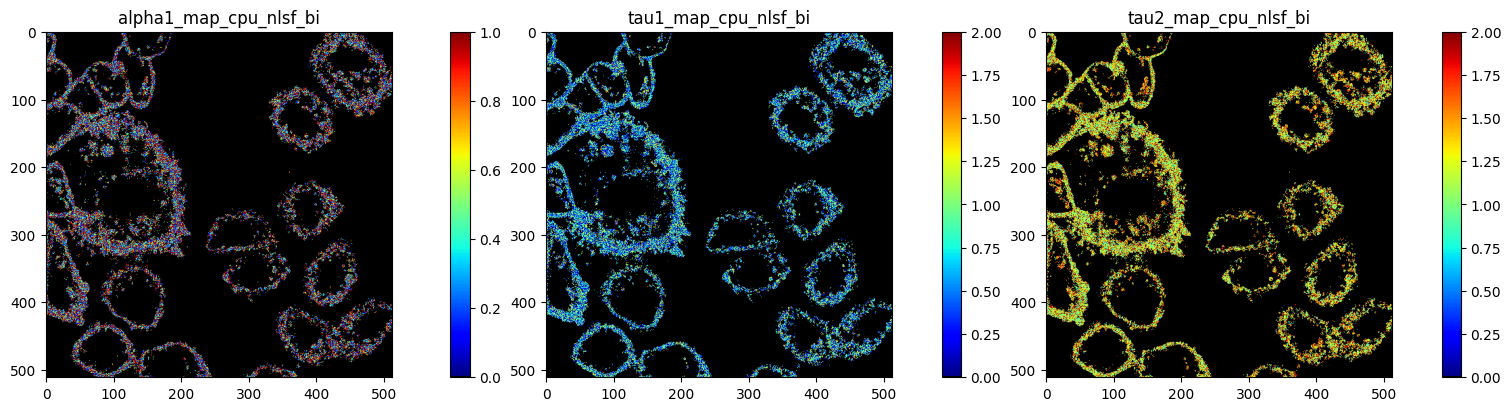

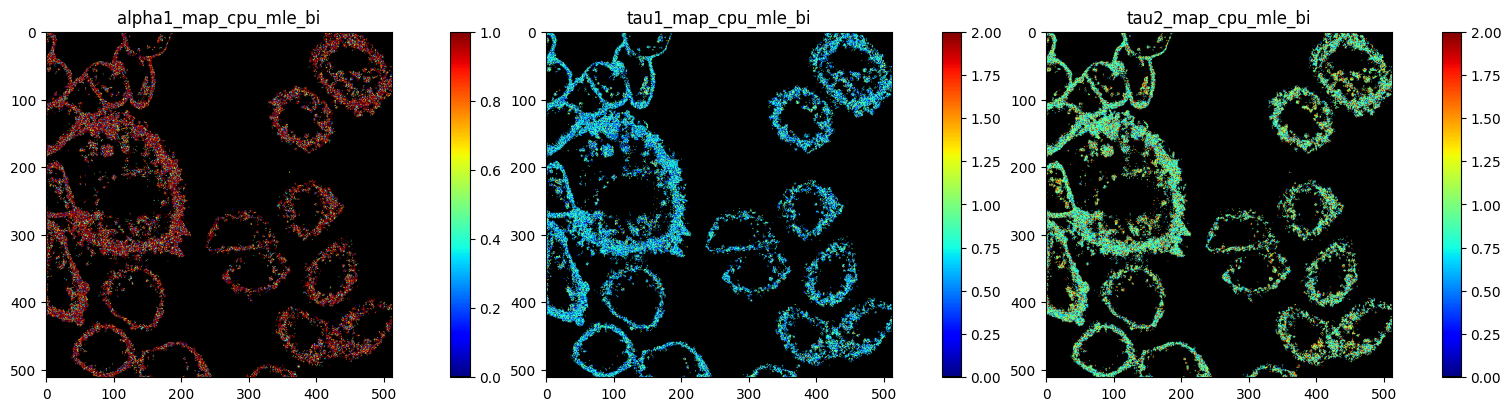

In [34]:
from pyfli.data_vnp import Plotter
all_datasets = []
all_fitset = []


for file_name, name_add in experiments.items():
    file_path = os.path.join(saver.save_dir, file_name)
    var  = np.load(file_path, allow_pickle=True).item()
    res_ = var['results']['maps']
    all_datasets.append(res_)
    all_fitset.append(var['results']['TR_maps'])

    if MODEL_TYPE == 'bi-exponential' :
        data_list  = [res_['alpha1_map'], res_['tau1_map'], res_['tau2_map']]
        data_names = [f'alpha1_map{name_add}', f'tau1_map{name_add}', f'tau2_map{name_add}']
        save_this = True
        viewer_kwargs = {'save_path': saver.save_dir, 'fig_name': name_add} if save_this else {}
        DataViewer(**viewer_kwargs).display_data(
            data_list, structure=(1, 3), coord=None,
            data_names=data_names, cmaps=[jet_m]*3,
            v_ranges=[(0,1),(0,2),(0,2)], 
            figsize=None, normalize=False, yscale='linear'
        )
    elif MODEL_TYPE == 'mono-exponential':
        data_list  = [res_['tau_map']]
        data_names = [f'tau_map{name_add}']
        save_this = True
        viewer_kwargs = {'save_path': saver.save_dir, 'fig_name': name_add} if save_this else {}
        DataViewer(**viewer_kwargs).display_data(
            data_list, structure=(1, 1), coord=None,
            data_names=data_names, cmaps=[jet_m]*1,
            v_ranges=[(0,2)], figsize=None, normalize=False, yscale='linear'
        )

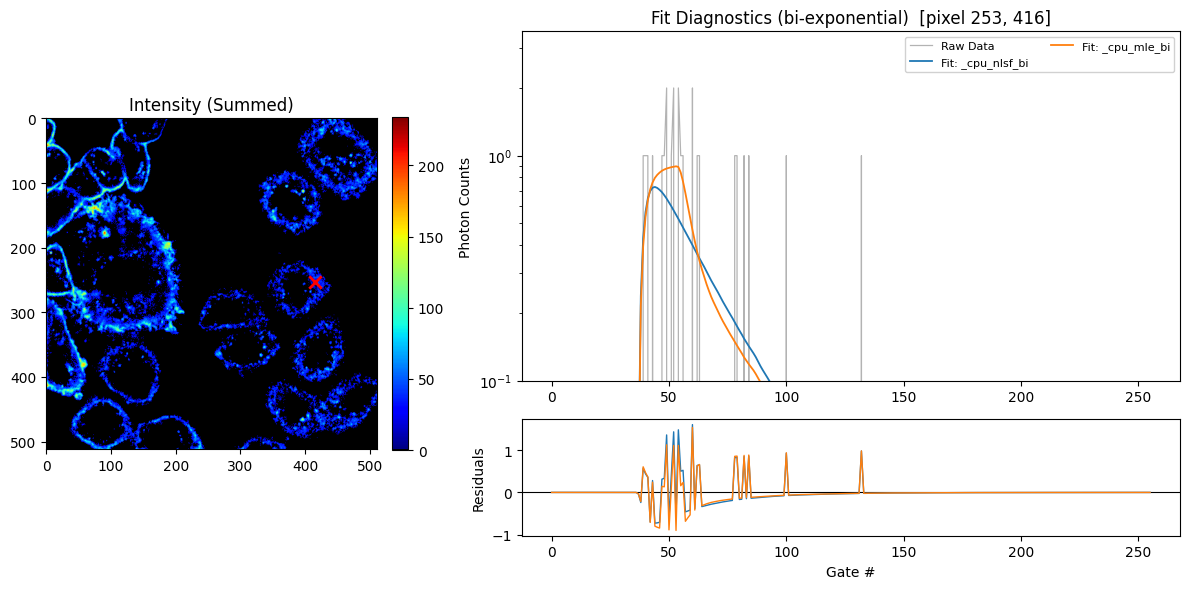

INFO:pyfli:IMAGE SAVED >> fit_log_diagnotics_bi-exponential_(253,416).png


In [35]:
from pyfli.analysis.utils import plot_pixel_diagnostic
names = list(experiments.values())
x,y = random_true_pixel(b_bool_mask)
im10 = plot_pixel_diagnostic(binned_decay,
                      all_fitset,
                      names,
                      mask=b_bool_mask,
                      pixel=(x, y),
                      t=None,
                      yscale=["linear","log"][1],
                      raw_style="line", 
                      model_type=MODEL_TYPE)
saver.save_plot('fit_log_diagnotics_'+f'{MODEL_TYPE}_({x},{y})', fig = im10, close=False)

INFO:pyfli:IMAGE SAVED >> comparative_analysis_bi-exponential_range_selection_grid.png
INFO:pyfli:IMAGE SAVED >> comparative_analysis_bi-exponential_fitset.png
INFO:pyfli:IMAGE SAVED >> comparative_analysis_bi-exponential_line_mean.png
INFO:pyfli:IMAGE SAVED >> comparative_analysis_bi-exponential_line_median.png
INFO:pyfli:IMAGE SAVED >> comparative_analysis_bi-exponential_box.png
INFO:pyfli:IMAGE SAVED >> comparative_analysis_bi-exponential_scatter.png


(<Figure size 1500x400 with 3 Axes>,
 array([[<Axes: title={'center': 'alpha1_map'}, xlabel='total_photons', ylabel='alpha1_map'>,
         <Axes: title={'center': 'tau1_map'}, xlabel='total_photons', ylabel='tau1_map'>,
         <Axes: title={'center': 'tau2_map'}, xlabel='total_photons', ylabel='tau2_map'>]],
       dtype=object))

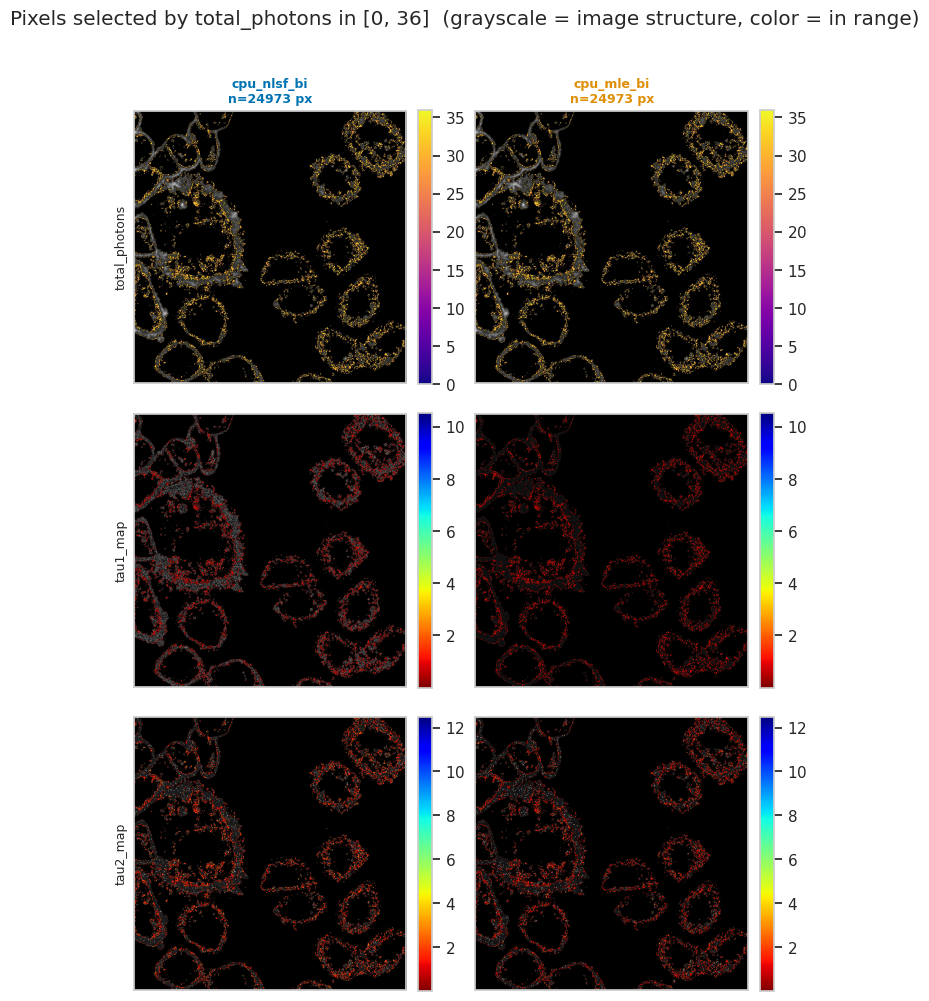

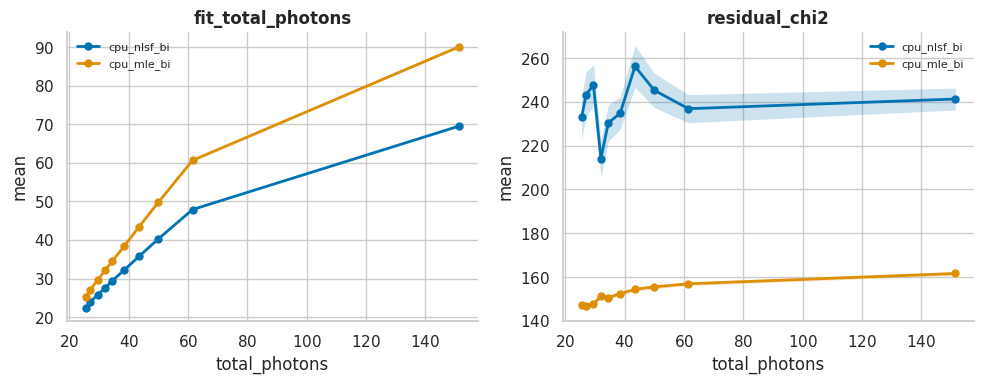

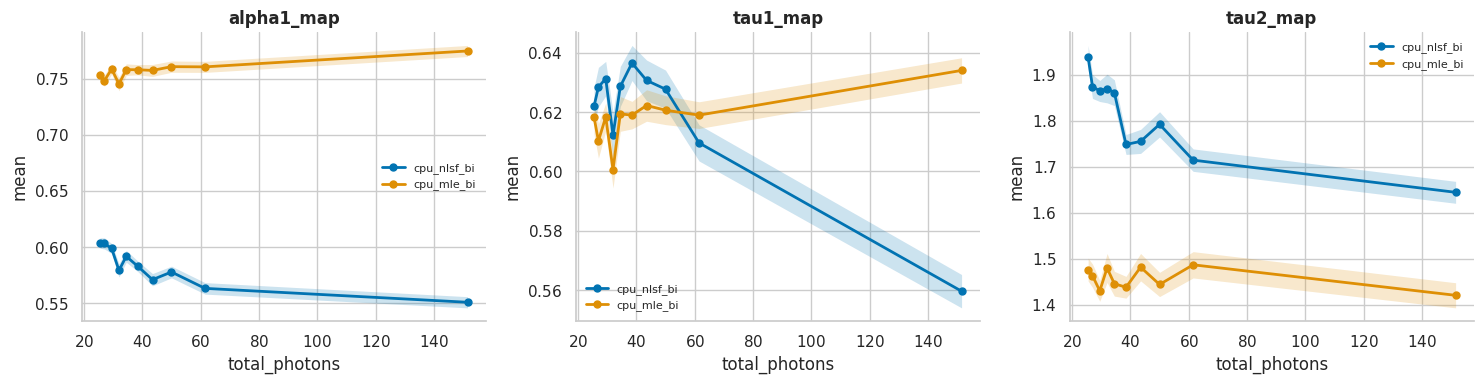

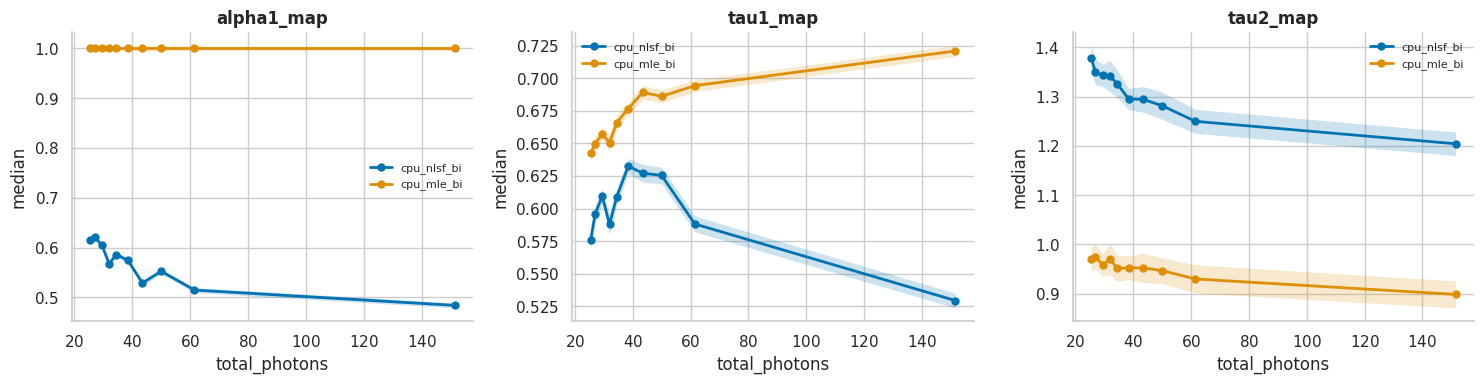

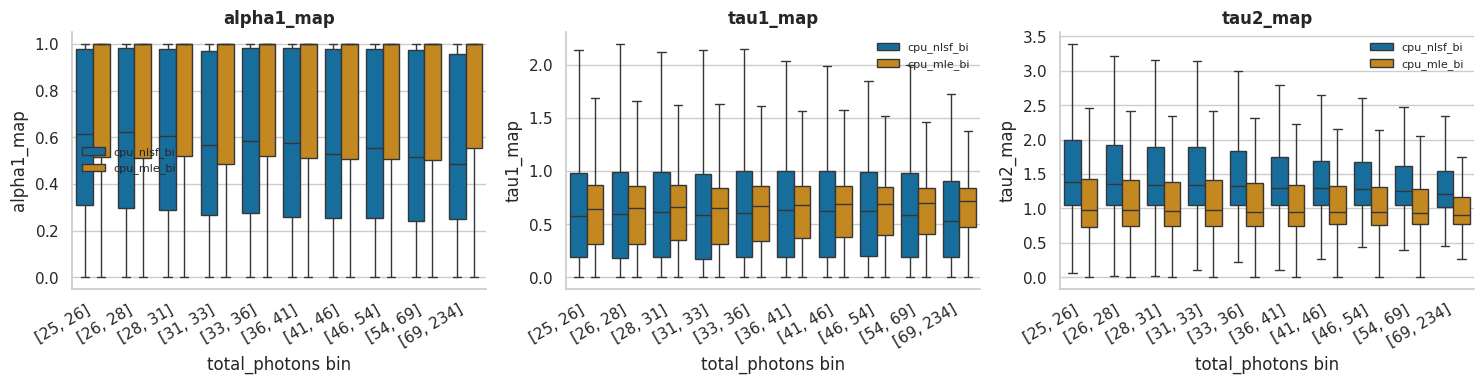

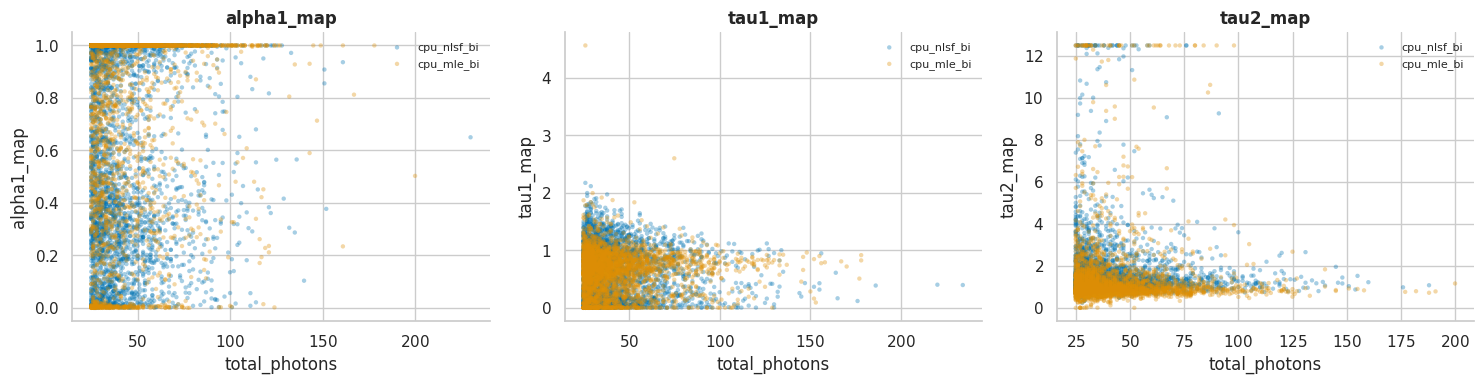

In [36]:
from pyfli.analysis import FactorAnalysis

fa = FactorAnalysis(decay=binned_decay, 
                    irf=binned_irf, 
                    mask=b_bool_mask,
                     all_datasets=all_datasets, 
                     all_fitset=all_fitset,
                     method_names=list(experiments.values()))
lo, hi = np.quantile(fa.factor_values('total_photons')[b_bool_mask], [0.45, 0.9])


fig, axes = fa.plot_range_selection_grid(
    'total_photons', (lo, hi),
    target_keys=['tau1_map', 'tau2_map'],
    cmap=['plasma', 'jet_r', 'jet_r'],   # [total_photons row, tau1_map row, tau2_map row]
    saver=saver, name=f"comparative_analysis_{MODEL_TYPE}_range_selection_grid",
)


df, edges = fa.analyze(factor_key='total_photons', target_source='fitset',
                        target_keys=['residual_chi2', 'fit_total_photons'])

fa.plot(df, saver=saver, name=f"comparative_analysis_{MODEL_TYPE}_fitset")

df, edges = fa.analyze(factor_key='total_photons', target_source='datasets',
                        target_keys=['alpha1_map', 'tau1_map', 'tau2_map'])
fa.plot(df, kind='line', stat='mean',
        saver=saver, name=f"comparative_analysis_{MODEL_TYPE}_line_mean")      # aggregated mean ± sem (original behavior)
fa.plot(df, kind='line', stat='median',
        saver=saver, name=f"comparative_analysis_{MODEL_TYPE}_line_median")    # aggregated median ± sem
fa.plot(df, kind='box',
        saver=saver, name=f"comparative_analysis_{MODEL_TYPE}_box")                    # boxplot of raw per-pixel values, per bin per method
fa.plot(df, kind='scatter', max_scatter_points=3000,
        saver=saver, name=f"comparative_analysis_{MODEL_TYPE}_scatter")  # raw unbinned factor vs. target scatter

INFO:pyfli:IMAGE SAVED >> comparative analysis_bi-exponential_violin.png
INFO:pyfli:Comparative Analysis of the paramters saved_bi-exponential_violin


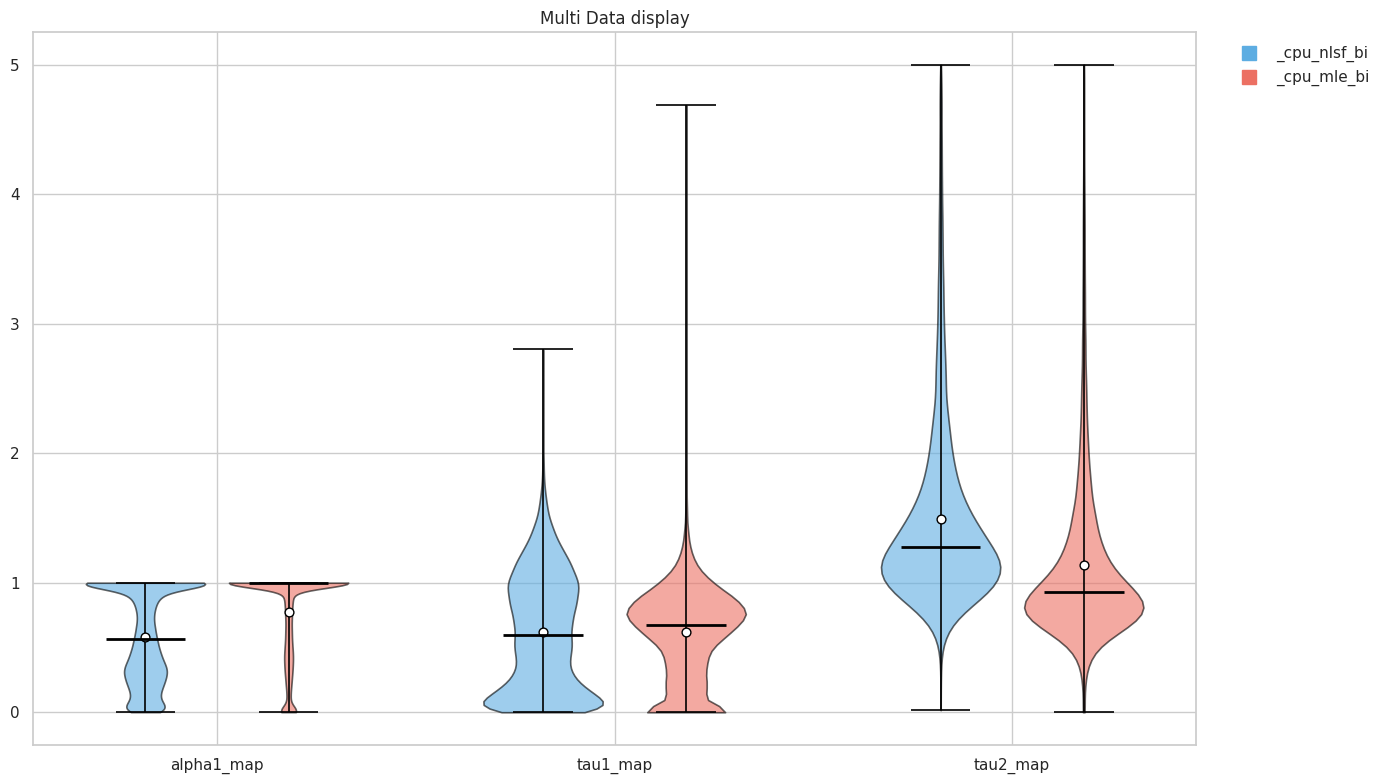

In [37]:
# Plotter — Data Operations Config
# ops_mode: 0 = none | 1 = shared (same ops for all sources) | 2 = per_source
ops_mode = ['none', 'shared', 'per_source'][2]
names = list(experiments.values())
masking = b_bool_mask.ravel()

_shared_ops = {
    "mask":            masking,   # restrict to ROI pixels only
    "remove_nan":      True,          # drop non-finite values (failed fits)
    "remove_zero":     True,          # drop exact zeros (masked / unfit pixels)
    "threshold":       (0, 2),        # keep values in [0, 2] — covers α∈[0,1] and τ∈[0,2 ns]
    "percentile_clip": (1, 99),       # clip extreme 1 % outliers from each end
    # "custom": lambda x: x,         # optional: any f(2D array) → 2D array
}

# ── Per-source: one dict per source, index-matched to all_datasets
thresh_up = 5
_per_source_ops = [
    # GT — fraction output α∈[0,1]; tau maps still [0,2]
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up)},
    # F-BI — fraction output α∈[0,1]; tau maps still [0,2]
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up)},
    # Laguerre — stable; standard mask + range check
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up)},
    # NLSF CPU
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up)},
    # NLSF GPU
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up)},
    # MLE CPU — Poisson fits can produce more extreme outliers; add percentile clip
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up), "percentile_clip": (2, 98)},
    # MLE GPU
    {"mask": masking, "remove_nan": True, "remove_zero": True, "threshold": (0, thresh_up), "percentile_clip": (2, 98)},
    
]

plotter_ops = {'none': None, 'shared': _shared_ops, 'per_source': _per_source_ops}[ops_mode]

# ─────────────────────────────────────────────────────────────────────────────
colors_list = [
    "#5DADE2", "#EC7063", "#58D68D", "#F4D03F", "#AF7AC5",
    "#EB984E", "#48C9B0", "#52BE80", "#AAB7B8", "#F1948A",
    "#BB8FCE", "#7FB3D5", "#76D7C4"
]
if MODEL_TYPE == 'bi-exponential':
    keys_to_plot = ['alpha1_map', 'tau1_map', 'tau2_map']
elif MODEL_TYPE == 'mono-exponential':
    keys_to_plot = ['tau_map']

painter = Plotter(
    *all_datasets,
    values       = keys_to_plot,
    style_config = colors_list,
    source_names = names,
    operations   = plotter_ops,
)

graph_type =['box', 'violin', 'swarm', 'overlay', 'raincloud', 'kde'][1]
t_test_type = ['none', 'paired', 'welch'][0]

fig = painter.make_plot(
    title             = "Multi Data display",
    graph_type        = graph_type, # param graph_type:'box', 'violin', 'swarm', 'overlay', 'raincloud', or 'kde'.
    point_type        = "strip",
    show_mean         = True,
    show_median       = True,   # Now shows as horizontal dash
    show_significance = True,
    test_type         = t_test_type,  # Options: 'paired' or 'welch'
    correction        = False,
)
saver.save_plot("comparative analysis"+f'_{MODEL_TYPE}_{graph_type}', fig = fig, close=False)
saver.log('Comparative Analysis of the paramters saved'+f'_{MODEL_TYPE}_{graph_type}')

In [38]:
from pyfli.data_vnp import ParamCorrelationMatrix
corel_loader = ParamCorrelationMatrix(all_datasets=all_datasets, 
                       bool_mask=b_bool_mask,
                       names=list(experiments.values()))

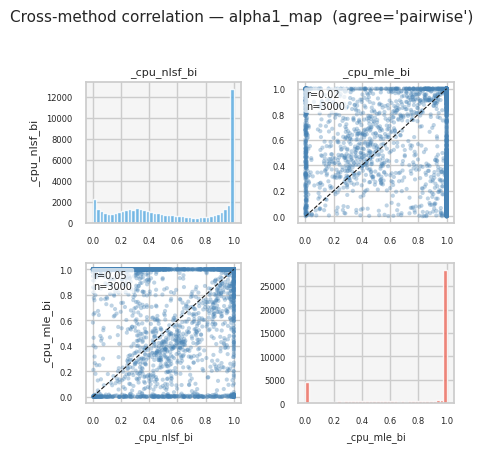

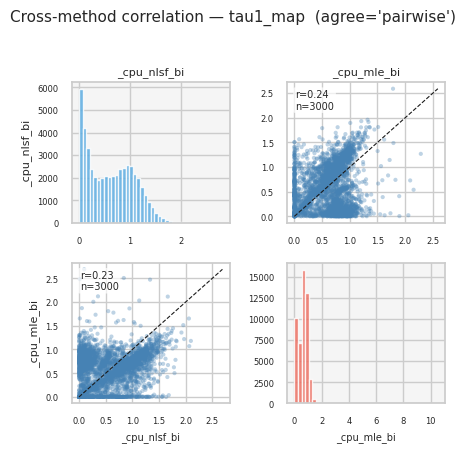

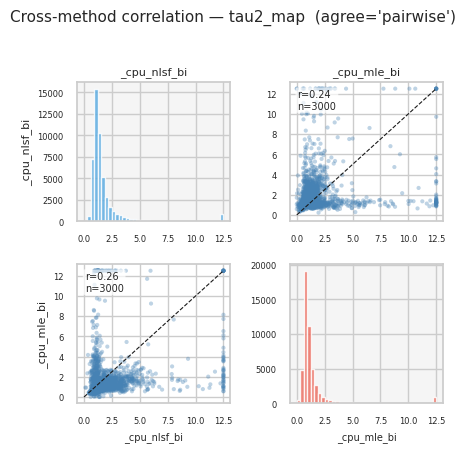

INFO:pyfli:IMAGE SAVED >> correl_rw_bi-exponential_alpha1.png
INFO:pyfli:IMAGE SAVED >> correl_rw_bi-exponential_tau1.png
INFO:pyfli:IMAGE SAVED >> correl_rw_bi-exponential_tau2.png


In [39]:
from pyfli.data_vnp import ParamCorrelationMatrix
corel_loader = ParamCorrelationMatrix(all_datasets=all_datasets, 
                       bool_mask=b_bool_mask,
                       names=list(experiments.values()))
if MODEL_TYPE == "bi-exponential":
    imcorel1 = corel_loader.scatter_matrix("alpha1_map",)
    imcorel2 = corel_loader.scatter_matrix("tau1_map",)
    imcorel3 = corel_loader.scatter_matrix("tau2_map",)
    save_this = True
    if save_this:
        saver.save_plot(name=f'correl_rw_{MODEL_TYPE}_alpha1', fig=imcorel1, close=False)
        saver.save_plot(name=f'correl_rw_{MODEL_TYPE}_tau1', fig=imcorel2, close=False)
        saver.save_plot(name=f'correl_rw_{MODEL_TYPE}_tau2', fig=imcorel3, close=False)

elif MODEL_TYPE == "mono-exponential":
    imcorel = corel_loader.scatter_matrix("tau_map",)
    save_this = True
    if save_this:
        saver.save_plot(name=f'correl_rw_{MODEL_TYPE}_tau', fig=imcorel, close=False)

INFO:pyfli:IMAGE SAVED >> alpha1_map_bi-exponential.png
INFO:pyfli:detail analysis of paramters alpha1_map saved
INFO:pyfli:IMAGE SAVED >> tau1_map_bi-exponential.png
INFO:pyfli:detail analysis of paramters tau1_map saved
INFO:pyfli:IMAGE SAVED >> tau2_map_bi-exponential.png
INFO:pyfli:detail analysis of paramters tau2_map saved


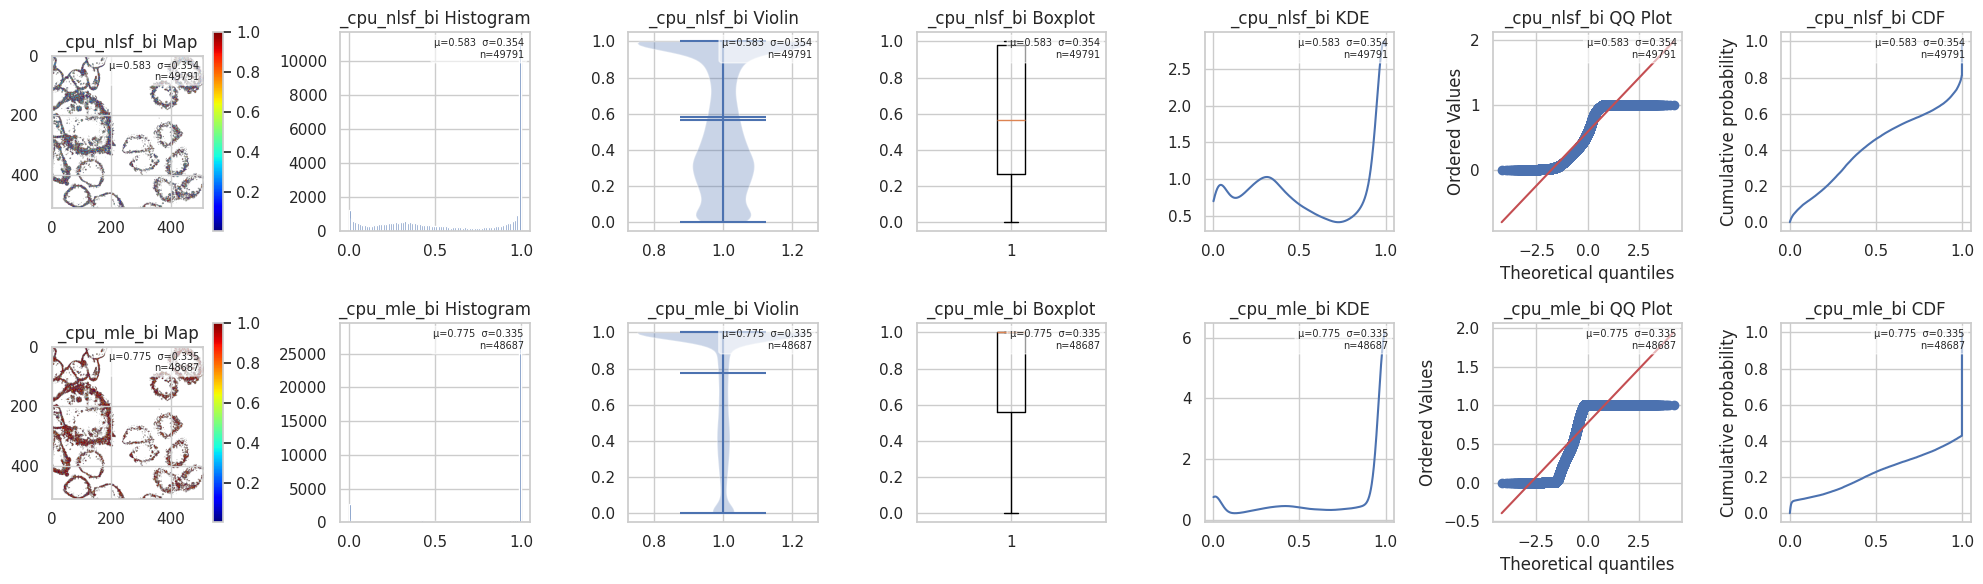

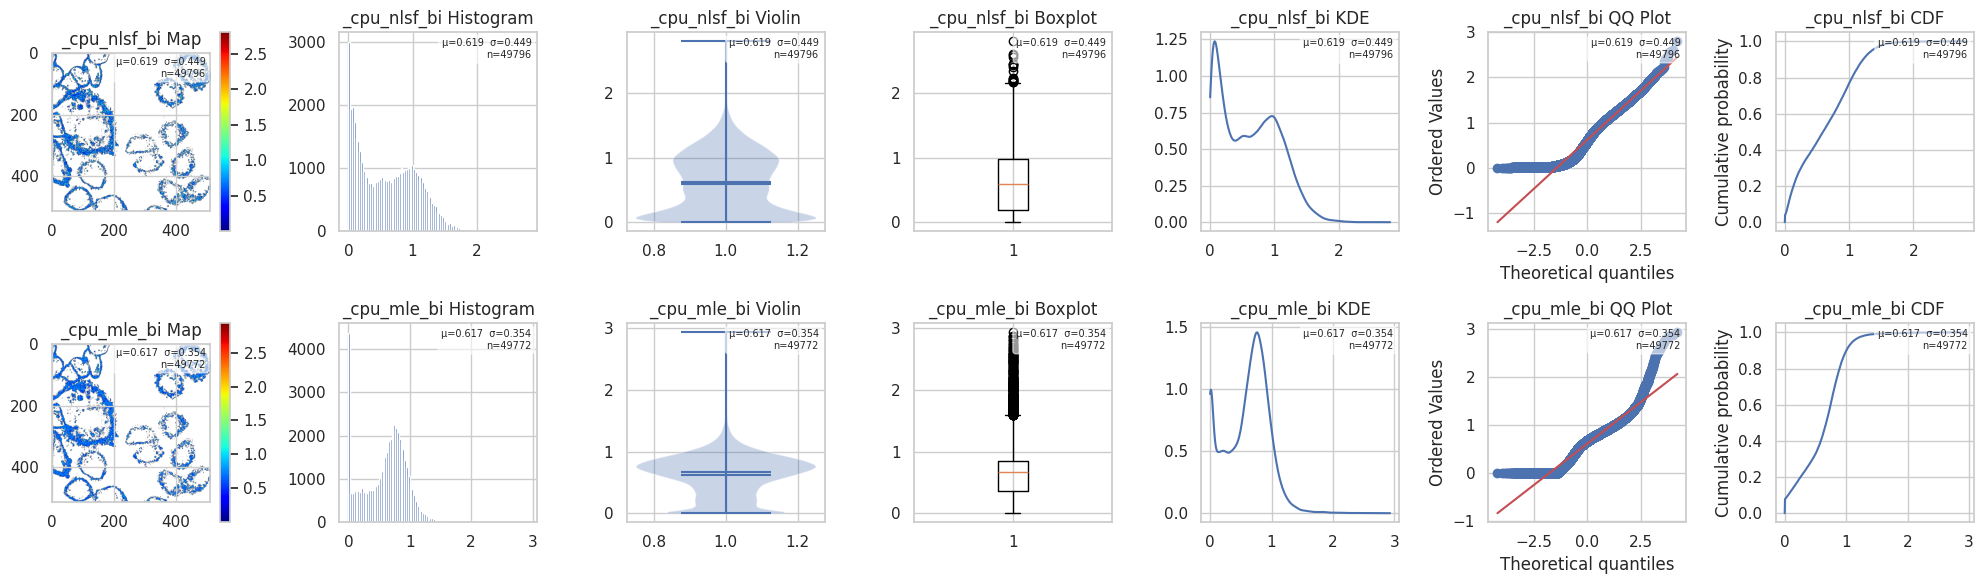

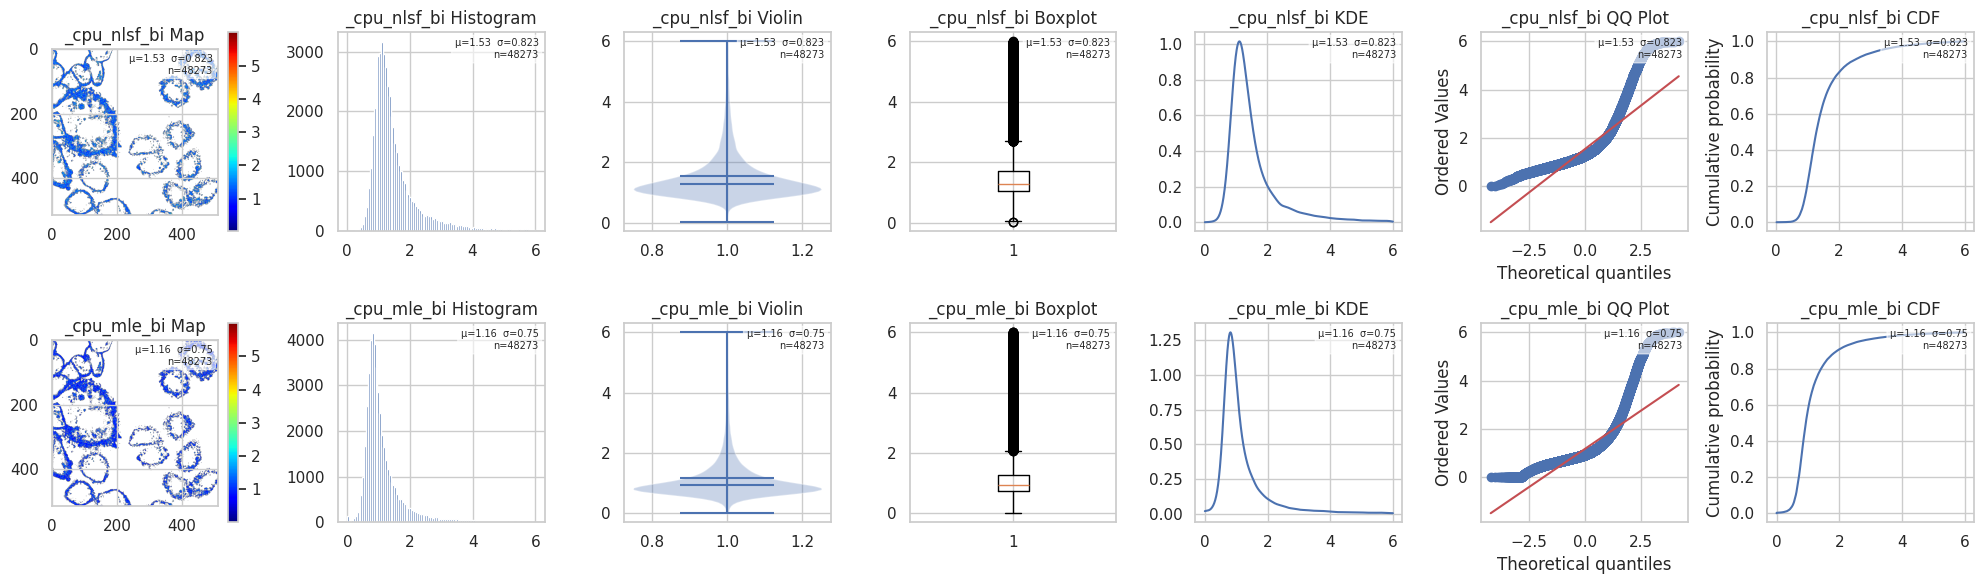

In [40]:
from pyfli.data_vnp import plot_2d_subplots
n = len(all_datasets)
if MODEL_TYPE == 'bi-exponential':
    map_names = ['alpha1_map', 'tau1_map', 'tau2_map']
    threshold_ = [(0, 1), (0, 3), (0, 6)]
elif MODEL_TYPE == 'mono-exponential':
    map_names = ['tau_map']
    threshold_ = [(0, 2.5)]


plot_types = ["map", "histogram", "violinplot", "boxplot", "KDE", "qq", "cdF"]
titles = names

current_mode = 'shared' # 'none', 'shared', or 'per_source'

for i, map_name in enumerate(map_names):
    datasets_to_plot = [dataset[map_name] for dataset in all_datasets[:6]]
    num_plots = len(datasets_to_plot)
    _shared_ops = {}
    _per_source_ops = []
    base_op = {
        "remove_nan": True,
        "remove_zero": True,
        "threshold": threshold_[i],
        "mask": b_bool_mask
    }

    if current_mode == 'shared':
        _shared_ops = base_op.copy()
        operations = [_shared_ops for _ in range(num_plots)]

    elif current_mode == 'per_source':
        _per_source_ops = [base_op.copy() for _ in range(num_plots)]
        operations = _per_source_ops

    else:  # current_mode == 'none'
        operations = [{
            "remove_nan": True,
            "remove_zero": True,
            "threshold": threshold_[i],
            "mask": None
        } for _ in range(num_plots)]

    # 4. Generate the Subplots
    fig = plot_2d_subplots(
        *datasets_to_plot,
        plot_types=plot_types,
        titles=titles[:num_plots],  # Match title count to dataset count safely
        operations=operations,
        figsize=(20, 3*len(names)),
        cmap='jet'
    )
    saver.save_plot(map_names[i]+f'_{MODEL_TYPE}', fig = fig, close= False)
    saver.log(f'detail analysis of paramters {map_names[i]} saved')

In [ ]:
from pyfli.data_vnp import MonoBiClassifier
if MODEL_TYPE == 'bi-exponential':
    clf = MonoBiClassifier(b_bool_mask,
                        names=names,
                        alpha_upper=0.95,
                        alpha_lower=0.05,
                        coord=None)
    classes = clf.classify(all_datasets, display= True)
check_category = ['mono', 'bi'][1]
if MODEL_TYPE == 'bi-exponential':    
    clf.agreement(metric="jaccard")                    # mono & bi overlap heatmaps
    clf.agreement(metric="count")
    if check_category == 'mono':
        imcm1 = clf.param_scatter_matrix("alpha1_map", cls="mono")
        imcm2 =clf.param_scatter_matrix("tau1_map", cls="mono")
        imcm3 =clf.param_scatter_matrix("tau2_map", cls="mono")
        save_this = True
        if save_this:
            saver.save_plot(name='correl_alpha1'+f'_{check_category}', fig=imcm1, close=False)
            saver.save_plot(name='correl_tau1'+f'_{check_category}', fig=imcm2, close=False)
            saver.save_plot(name='correl_tau2'+f'_{check_category}', fig=imcm3, close=False)

    elif check_category == 'bi':
        imcb1 = clf.param_scatter_matrix("alpha1_map", cls="bi")
        imcb2 =clf.param_scatter_matrix("tau1_map", cls="bi")
        imcb3 =clf.param_scatter_matrix("tau2_map", cls="bi")
        save_this = True
        if save_this:
            saver.save_plot(name='correl_alpha1'+f'_{check_category}', fig=imcb1, close=False)
            saver.save_plot(name='correl_tau1'+f'_{check_category}', fig=imcb2, close=False)
            saver.save_plot(name='correl_tau2'+f'_{check_category}', fig=imcb3, close=False)
    else:
        raise ValueError('the right category is not selected')
    df = clf.agreed_param_table(cls="mono")
    print(df.groupby("method")[["alpha1_map", "tau1_map", "tau2_map"]].describe())

the non-zero pixel selected for probing is (14, 436)


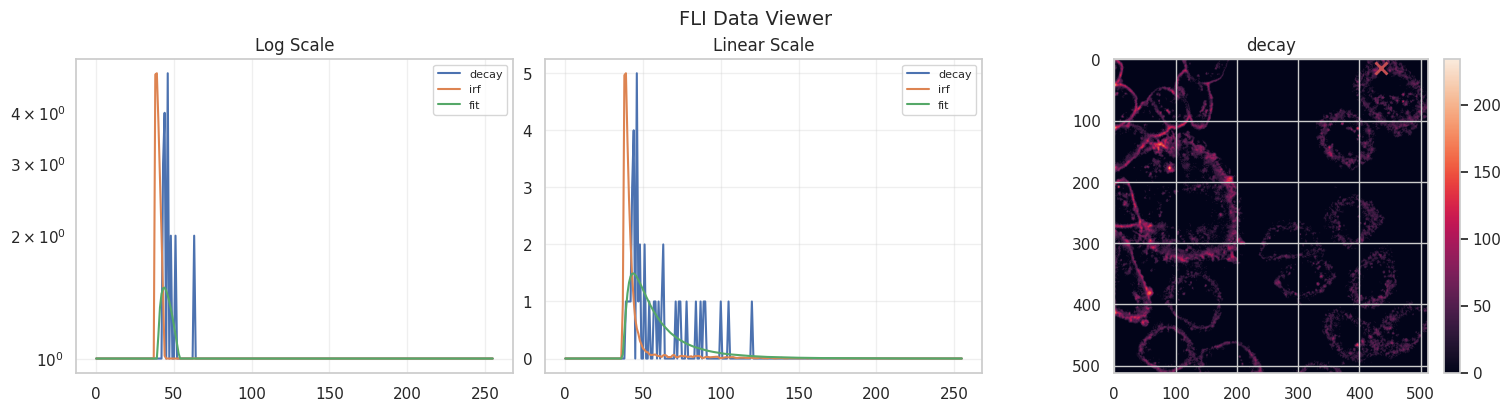

INFO:pyfli:
  Pixel (14, 436)
  ─────────────────────
  A         1.6450
  α         1.0000
  τ₁        0.7748
  τ₂        0.7748
  R²        0.4119
  Red.χ²    0.1478
  Raw.χ²    36.9550
  v-shift   0.0000
  h-shift   0.0977
  ─────────────────────



In [41]:
from pyfli import Normalization
from pyfli.data_vnp import DataViewer
from pyfli.data_text import MessageDisplay
x,y = random_true_pixel(b_bool_mask)
data_out = 1
TRs = all_fitset[data_out]
maps = all_datasets[data_out]
print(f'the non-zero pixel selected for probing is ({x}, {y})')
irf_norm= Normalization(binned_irf).norm_scale(binned_decay)
viewer_kwargs = {'save_path': saver.save_dir, 'fig_name': f"fitting_evidence at ({x},{y})"}
DataViewer(**viewer_kwargs).plot_fli_px(data_list=[binned_decay, irf_norm, TRs['fit_map'], TRs['residual_map']],
                         pixel=(x,y),
                         mode=[0,1,2],
                         mode2=[0],
                         names = ['decay', 'irf', 'fit'])
px_params = MessageDisplay().get_pixel_summary(data_maps=maps, px=(x,y))

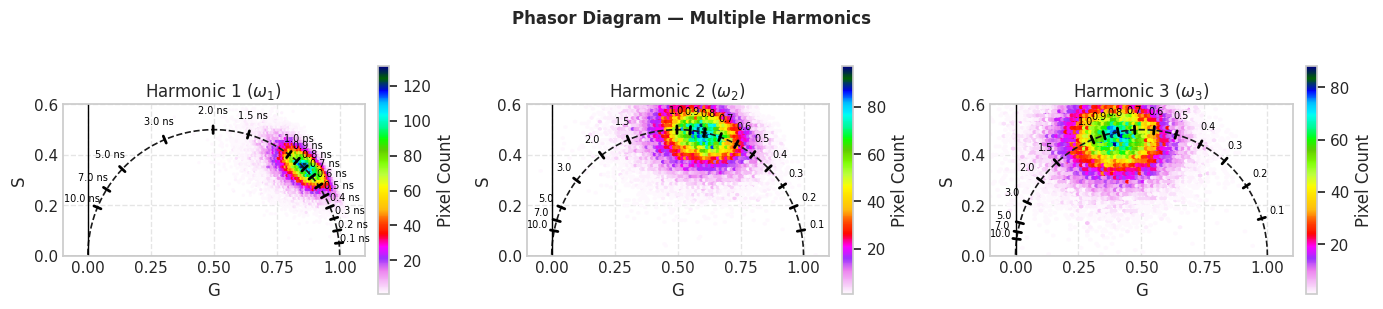

In [43]:
cols_ = ["gist_ncar_r","PuBuGn", "YlGnBu", "BuPu"][0]
im3 = Phasor_binned.plot_phasor_harmonics(binned_Gc, binned_Sc,
                                    harmonics=(1, 2, 3),
                                    mask = b_bool_mask,
                                    hexbin_color = cols_,
                                    figsize=(14,3))
if save_this:
    saver.save_plot(name='phasor_harmonics_Plot', fig=im3, close=False)

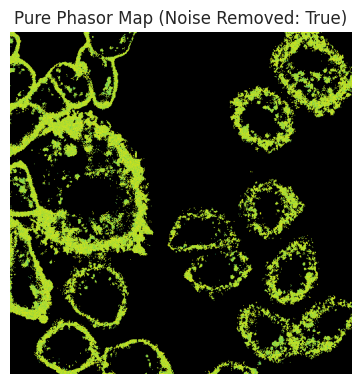

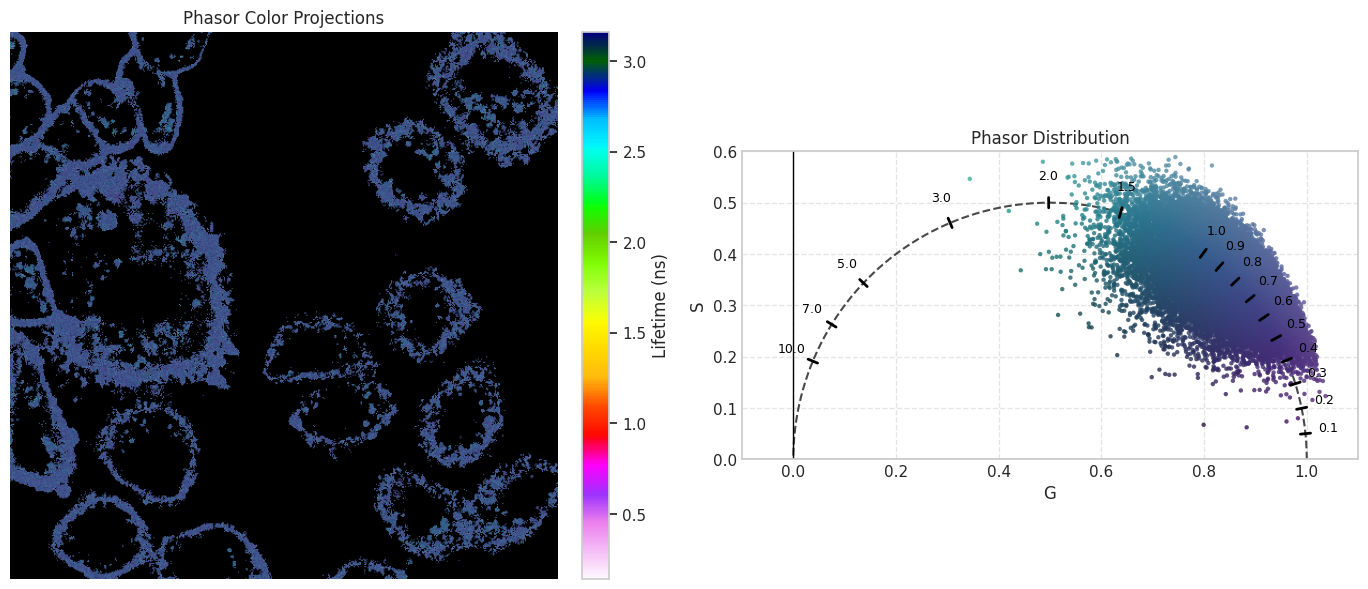

In [45]:
# Pure phasor map — each pixel colored by its phasor phase angle (encodes apparent lifetime)
im4 = Phasor_binned.plot_pure_phasor_map(binned_Gc[0], binned_Sc[0], binned_decay,
                                          noise_removed=True, colormap='viridis')
save_this = False
if save_this:
    saver.save_plot(name='phasor_pure_map', fig=im4, close=False)
plt.show()

# Traceable analysis — radial-color spatial map paired with annotated phasor diagram
im5 = Phasor_binned.plot_traceable_analysis(binned_Gc[0], binned_Sc[0],
                                             mask=b_bool_mask, colormap=cols_)
if save_this:
    saver.save_plot(name='phasor_traceable', fig=im5, close=False)
plt.show()